# Press Release Chart
## S&P 500 Sector Weights
This notebook generates the visualization used in the project press release.
It uses approximate S&P 500 sector weights as of 2024 (sourced from SPDR ETF fact sheets).

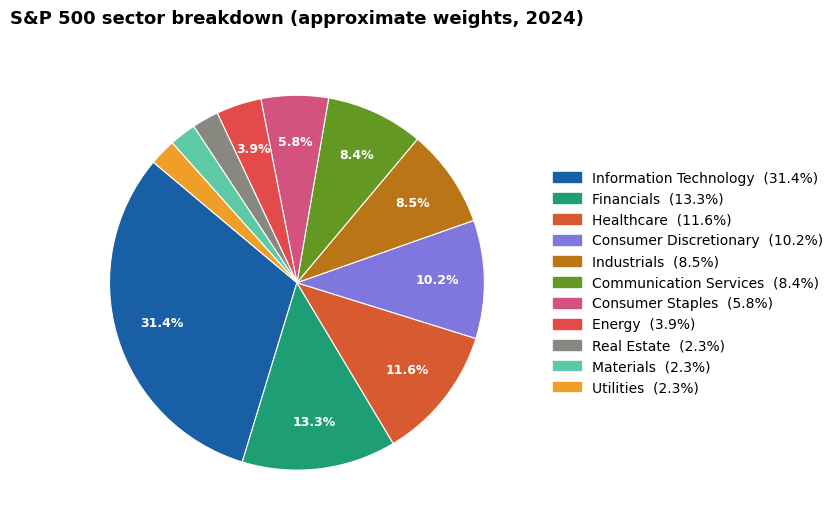

Chart saved to results/sector_weights.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# Approximate S&P 500 sector weights as of 2024
# Source: SPDR ETF fact sheets (State Street Global Advisors)
sectors = {
    "Information Technology": 31.4,
    "Financials":             13.3,
    "Healthcare":             11.6,
    "Consumer Discretionary": 10.2,
    "Industrials":             8.5,
    "Communication Services":  8.4,
    "Consumer Staples":        5.8,
    "Energy":                  3.9,
    "Real Estate":             2.3,
    "Materials":               2.3,
    "Utilities":               2.3,
}

labels  = list(sectors.keys())
weights = list(sectors.values())

# Color palette — one distinct color per sector
colors = [
    "#185FA5",  # tech — blue
    "#1D9E75",  # financials — teal
    "#D85A30",  # healthcare — coral
    "#7F77DD",  # consumer disc — purple
    "#BA7517",  # industrials — amber
    "#639922",  # comm services — green
    "#D4537E",  # consumer staples — pink
    "#E24B4A",  # energy — red
    "#888780",  # real estate — gray
    "#5DCAA5",  # materials — light teal
    "#EF9F27",  # utilities — light amber
]

# Style
plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "font.size":          11,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   False,
    "axes.spines.bottom": False,
})

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    weights,
    labels=None,
    colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p >= 3.5 else "",
    pctdistance=0.75,
    startangle=140,
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# Legend on the right
legend_labels = [f"{s}  ({w}%)" for s, w in zip(labels, weights)]
legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(len(labels))]
ax.legend(
    handles=legend_patches,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10,
)

ax.set_title(
    "S&P 500 sector breakdown (approximate weights, 2024)",
    fontsize=13,
    fontweight="bold",
    pad=18,
)

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/sector_weights.png", bbox_inches="tight", dpi=150)
plt.show()
print("Chart saved to results/sector_weights.png")